# Exercise 2 - Penicillin 

***Overall kinetics***

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


mu_m = 0.2       
Ks   = 0.5      
Ki   = 50.0   
Yxs  = 0.3      
qp   = 0.08     

F        = 50.0    
Sf       = 100.0  
V0       = 200.0   
Vmax     = 800.0   
Vwithdraw = 600.0  

S_init   = 0.0     
X_init   = 30.0   
P_init   = 0.0     

n_cycles = 10
t_cycle  = (Vmax - V0) / F  


def mu_inhibition(S):
    S = max(S, 0.0)
    return mu_m * S / (Ks + S + S**2 / Ki)

def mu_no_inhibition(S):
    S = max(S, 0.0)
    return mu_m * S / (Ks + S)


def reactor_model(t, y, mu_func, S_feed):
    S, X, P = y
    V = V0 + F * t

    mu = mu_func(S)

    dSdt = (F / V) * (S_feed - S) - (1.0 / Yxs) * mu * X
    dXdt = mu * X - (F / V) * X
    dPdt = qp * X - (F / V) * P

    return [dSdt, dXdt, dPdt]

def simulate_cycles(mu_func, S_feed=Sf, n_cycles=10):
    S0, X0, P0 = S_init, X_init, P_init

    time_total = []
    S_total = []
    X_total = []
    P_total = []

    removed_product_each_cycle_kg = []
    time_shift = 0.0

    for cycle in range(n_cycles):
        sol = solve_ivp(
            lambda t, y: reactor_model(t, y, mu_func, S_feed),
            [0, t_cycle],
            [S0, X0, P0],
            method='RK45',
            t_eval=np.linspace(0, t_cycle, 400),
            max_step=0.05
        )

        t = sol.t + time_shift
        S = sol.y[0]
        X = sol.y[1]
        P = sol.y[2]

        if cycle == 0:
            time_total.extend(t)
            S_total.extend(S)
            X_total.extend(X)
            P_total.extend(P)
        else:
            time_total.extend(t[1:])
            S_total.extend(S[1:])
            X_total.extend(X[1:])
            P_total.extend(P[1:])

        S_end = max(S[-1], 0.0)
        X_end = max(X[-1], 0.0)
        P_end = max(P[-1], 0.0)


        removed_product_each_cycle_kg.append(P_end * Vwithdraw / 1000.0)

        S0, X0, P0 = S_end, X_end, P_end
        time_shift += t_cycle

    return {
        "t": np.array(time_total),
        "S": np.array(S_total),
        "X": np.array(X_total),
        "P": np.array(P_total),
        "removed_product_each_cycle_kg": np.array(removed_product_each_cycle_kg)
    }

***Question b***

In [10]:
print(f"Cycle time = {t_cycle:.2f} h")

Cycle time = 12.00 h


***Question c***

Total product removed after 10 cycles = 136.8731 kg


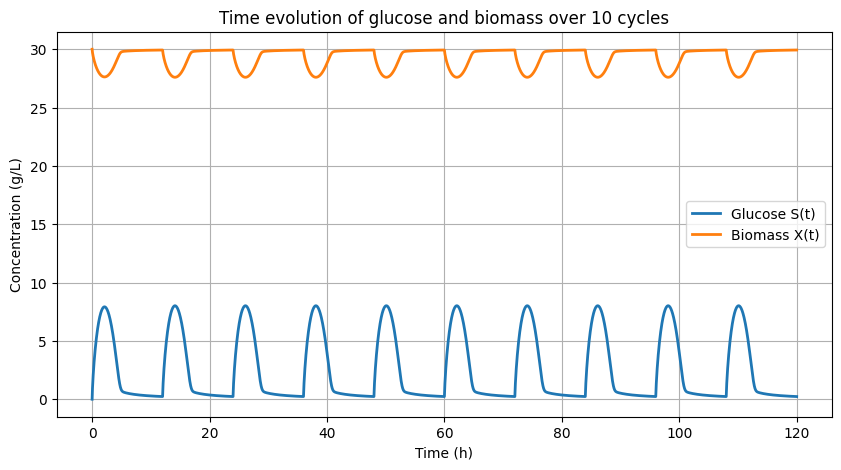

In [11]:
result = simulate_cycles(mu_inhibition, S_feed=Sf, n_cycles=10)

print(f"Total product removed after 10 cycles = {result['removed_product_each_cycle_kg'].sum():.4f} kg")

plt.figure(figsize=(10, 5))
plt.plot(result["t"], result["S"], label="Glucose S(t)", linewidth=2)
plt.plot(result["t"], result["X"], label="Biomass X(t)", linewidth=2)
plt.xlabel("Time (h)")
plt.ylabel("Concentration (g/L)")
plt.title("Time evolution of glucose and biomass over 10 cycles")
plt.grid(True)
plt.legend()
plt.show()

***Question d***

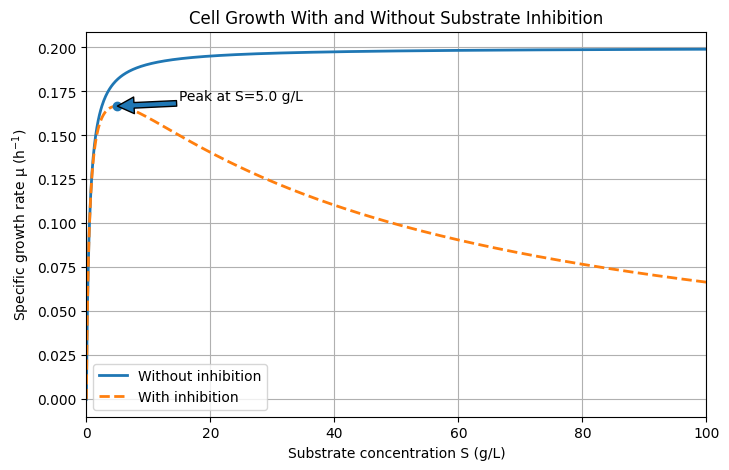

In [12]:
S_range = np.linspace(0, 100, 1000)

mu_monod = np.array([mu_no_inhibition(S) for S in S_range])
mu_inhib = np.array([mu_inhibition(S) for S in S_range])

S_opt = np.sqrt(Ks * Ki)
mu_opt = mu_inhibition(S_opt)

plt.figure(figsize=(8, 5))
plt.plot(S_range, mu_monod, label="Without inhibition", linewidth=2)
plt.plot(S_range, mu_inhib, "--", label="With inhibition", linewidth=2)
plt.scatter(S_opt, mu_opt, zorder=3)
plt.annotate(f"Peak at S={S_opt:.1f} g/L",
             (S_opt, mu_opt),
             xytext=(15, 0.17),
             arrowprops=dict())

plt.xlabel("Substrate concentration S (g/L)")
plt.ylabel("Specific growth rate μ (h$^{-1}$)")
plt.title("Cell Growth With and Without Substrate Inhibition")
plt.xlim(0, 100)
plt.grid(True)
plt.legend()
plt.show()

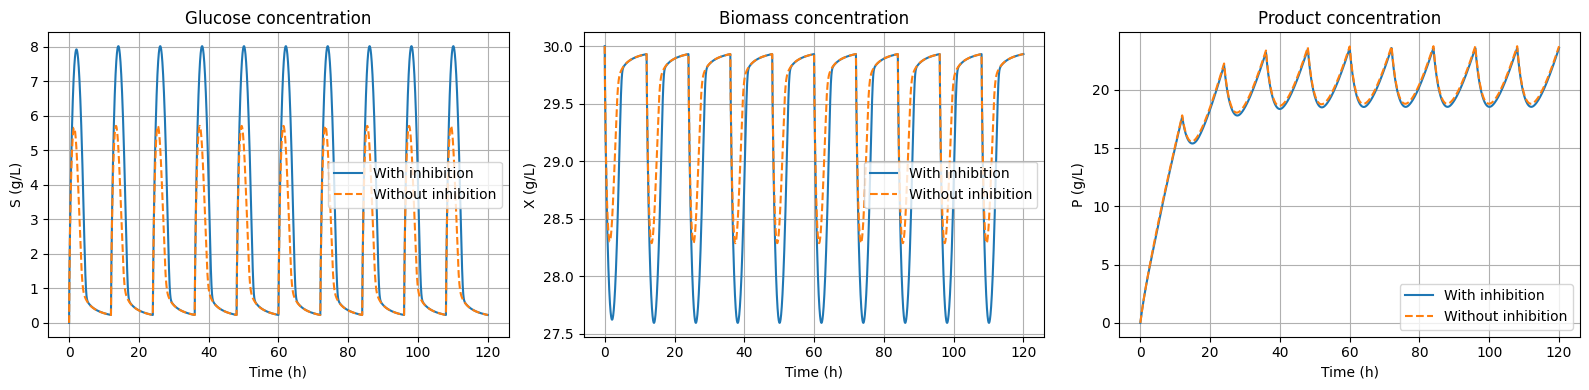

In [13]:
res_inhib = simulate_cycles(mu_inhibition, S_feed=Sf, n_cycles=10)
res_no_inhib = simulate_cycles(mu_no_inhibition, S_feed=Sf, n_cycles=10)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(res_inhib["t"], res_inhib["S"], label="With inhibition")
axes[0].plot(res_no_inhib["t"], res_no_inhib["S"], "--", label="Without inhibition")
axes[0].set_title("Glucose concentration")
axes[0].set_xlabel("Time (h)")
axes[0].set_ylabel("S (g/L)")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(res_inhib["t"], res_inhib["X"], label="With inhibition")
axes[1].plot(res_no_inhib["t"], res_no_inhib["X"], "--", label="Without inhibition")
axes[1].set_title("Biomass concentration")
axes[1].set_xlabel("Time (h)")
axes[1].set_ylabel("X (g/L)")
axes[1].grid(True)
axes[1].legend()

axes[2].plot(res_inhib["t"], res_inhib["P"], label="With inhibition")
axes[2].plot(res_no_inhib["t"], res_no_inhib["P"], "--", label="Without inhibition")
axes[2].set_title("Product concentration")
axes[2].set_xlabel("Time (h)")
axes[2].set_ylabel("P (g/L)")
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()

***Question f***

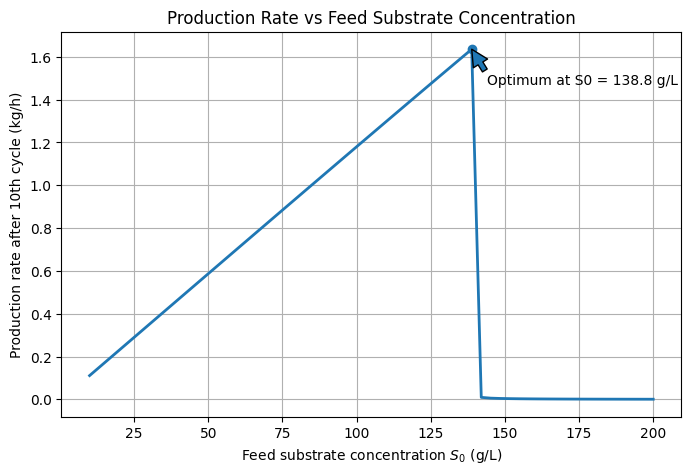

Optimal feed substrate concentration = 138.81 g/L
Maximum production rate = 1.6356 kg/h


In [ ]:
S_feed_values = np.linspace(10, 200, 60)
production_rates_kg_h = []

for S_feed in S_feed_values:
    result = simulate_cycles(mu_inhibition, S_feed=S_feed, n_cycles=10)

    mP_10th_cycle = result["removed_product_each_cycle_kg"][-1]   
    rate = mP_10th_cycle / t_cycle                                
    production_rates_kg_h.append(rate)

production_rates_kg_h = np.array(production_rates_kg_h)

idx_opt = np.argmax(production_rates_kg_h)
S_feed_opt = S_feed_values[idx_opt]
rate_opt = production_rates_kg_h[idx_opt]

plt.figure(figsize=(8, 5))
plt.plot(S_feed_values, production_rates_kg_h, linewidth=2)
plt.scatter(S_feed_opt, rate_opt, zorder=3)


plt.xlabel("Feed substrate concentration $S_0$ (g/L)")
plt.ylabel("Production rate after 10th cycle (kg/h)")
plt.title("Production Rate vs Feed Substrate Concentration")
plt.grid(True)
plt.show()

print(f"Optimal feed substrate concentration = {S_feed_opt:.2f} g/L")
print(f"Maximum production rate = {rate_opt:.4f} kg/h")